In [ ]:
groq_api_key='gsk_Du3'
langsmith='lsv_pt_d54'

In [5]:
pip install langchain langchain_groq langchain_community langgraph

  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached langchain_core-1.4.7-py3-none-any.whl.metadata (4.5 kB)
  Using cached langchain_text_splitters-1.1.2-py3-none-any.whl.metadata (3.3 kB)
Using cached langchain_community-0.4.2-py3-none-any.whl (2.4 MB)
Using cached httpx_sse-0.4.3-py3-none-any.whl (9.0 kB)
Using cached langchain_classic-1.0.8-py3-none-any.whl (1.0 MB)
Using cached langchain_core-1.4.7-py3-none-any.whl (554 kB)
Using cached langchain_text_splitters-1.1.2-py3-none-any.whl (35 kB)

  Attempting uninstall: langchain-core

    Found existing installation: langchain-core 1.4.0

   -------- ------------------------------- 1/5 [langchain-core]
    Uninstalling langchain-core-1.4.0:
   -------- ------------------------------- 1/5 [langchain-core]
      Successfully uninstalled langchain-core-1.4.0
   

In [6]:
from langchain_groq import ChatGroq
llm=ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")
llm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.4'}}, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F949A12F90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F949A13CB0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [8]:
class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [9]:
graph_builder

In [10]:
def chatbot(state:State):
  return {"messages":llm.invoke(state['messages'])}

In [11]:
graph_builder.add_node("chatbot",chatbot)


In [12]:
graph_builder

In [13]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)


In [14]:
graph=graph_builder.compile()

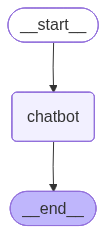

In [15]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [ ]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value["messages"].content)

dict_values([{'messages': AIMessage(content="MCP can refer to several things:\n\n1. **Microsoft Certified Professional**: A certification program offered by Microsoft for IT professionals.\n2. **Major Chip Package** or **Microprocessor Control Panel**: Terms related to computer hardware and electronics.\n3. **Methylcyclopentadienyl** (MCP): A chemical compound used in various industrial applications.\n4. **Maximum Contaminant Level** (MCL) **Permissible** or **MCP**: Terms related to environmental regulations and water quality.\n5. **Master Control Program**: A term used in science fiction, particularly in the movie Tron, to refer to a powerful artificial intelligence system.\n\nWithout more context, it's difficult to determine which definition is most relevant. If you have any additional information or clarification, I'd be happy to try and provide a more specific answer.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 172, 'prompt_tokens': 37, 'total_t